In [1]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Define function and create mock data
def f(x):
    """The 'Truth' we are trying to learn."""
    return 0.6 * x**4 + 2 * x**3 - 8 * x**2

def create_data(l, noise):
    """Generates a small, noisy training set."""
    x = np.random.uniform(-1, 3, l).reshape(-1, 1)
    y = f(x).flatten() + np.random.normal(0, noise, l)
    return x, y

In [3]:
# Spaghetti plot: Train multiple models on the same distribution, but different seeds.
def plot_spaghetti(degree, l=20, noise=2, repeats=15):
    """Plots multiple fits to show how much the model varies with new data."""
    x_range = np.linspace(-1, 3, 200).reshape(-1, 1)
    plt.figure(figsize=(10, 5))
    
    # Plot True Function
    plt.plot(x_range, f(x_range), c="black", linewidth=4, label="Target f(x)", zorder=10)
    
    # Plot multiple random fits
    for i in range(repeats):
        X_train, y_train = create_data(l, noise)
        poly = PolynomialFeatures(degree)
        model = LinearRegression().fit(poly.fit_transform(X_train), y_train)
        
        y_hat = model.predict(poly.transform(x_range))
        plt.plot(x_range, y_hat, alpha=0.3, c="red" if degree > 4 else "blue")
    
    plt.title(f"Model Complexity: Degree {degree} ({repeats} different training sets)")
    plt.ylim(-25, 25)
    plt.legend()
    plt.show()

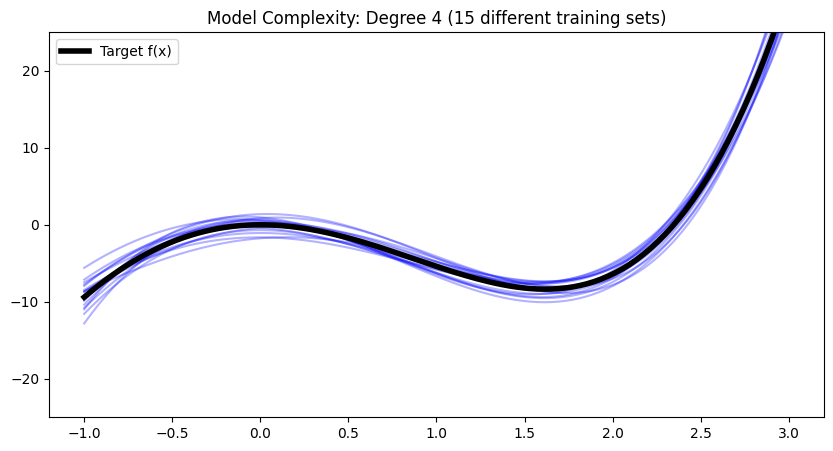

In [7]:
# Try for 1, 3, 5 and 10
plot_spaghetti(degree=4) # High Bias (Underfitting)

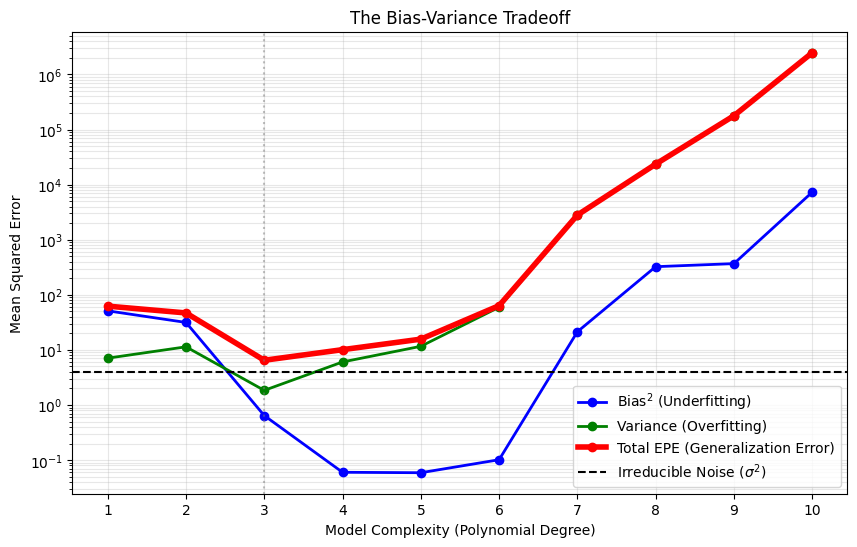

In [8]:
noise = 2
l = 20
repeats = 200
degrees = range(1, 11)

# Evaluation points (to calculate error across the whole domain)
x_test = np.linspace(-1, 3, 100).reshape(-1, 1)
y_test_true = f(x_test).flatten()

bias_sq_results = []
variance_results = []

for degree in degrees:
    all_predictions = []
    
    for i in range(repeats):
        X_train, y_train = create_data(l, noise)
        poly = PolynomialFeatures(degree)
        model = LinearRegression().fit(poly.fit_transform(X_train), y_train)
        y_hat = model.predict(poly.transform(x_test))
        all_predictions.append(y_hat)
        
    all_predictions = np.array(all_predictions) # (repeats, test_points)
    
    # Expected Prediction (The "Average" Learner)
    avg_prediction = np.mean(all_predictions, axis=0) # (test_points,)
    
    # Squared Bias: (Avg Prediction - Truth)^2
    bias_sq = np.mean((avg_prediction - y_test_true) ** 2)
    
    # Variance: How much models vary around their own mean
    variance = np.mean(np.var(all_predictions, axis=0))
    
    bias_sq_results.append(bias_sq)
    variance_results.append(variance)

# TODO: Expected Prediction Error (EPE)
# EPE = Bias^2 + Variance + Irreducible Noise
irreducible_error = noise ** 2
epe = np.array(bias_sq_results) + np.array(variance_results) + irreducible_error


plt.figure(figsize=(10, 6))

plt.plot(degrees, bias_sq_results, 'b-o', label='$\\text{Bias}^2$ (Underfitting)', linewidth=2)
plt.plot(degrees, variance_results, 'g-o', label='Variance (Overfitting)', linewidth=2)
plt.plot(degrees, epe, 'r-o', label='Total EPE (Generalization Error)', linewidth=4)
plt.axhline(irreducible_error, color='k', linestyle='--', label='Irreducible Noise ($\\sigma^2$)')

# Formatting
plt.yscale('log')
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean Squared Error")
plt.title("The Bias-Variance Tradeoff")
plt.xticks(degrees)
plt.grid(True, which="both", alpha=0.3)
plt.legend()

# Highlight the optimal capacity
best_degree = degrees[np.argmin(epe)]
plt.axvline(best_degree, color='gray', alpha=0.5, linestyle=':')


plt.show()